In [1]:
import torch as th
import numpy as np
import torch.nn as nn
import torch.optim as opt
import matplotlib.pyplot as plt
import scipy.io as sio
import time
import os
import pandas as pd
import scipy.signal as scs
from tqdm import tqdm
import seaborn as sns

import sys
sys.path.append('..')

from soft_tex.model.parallel_net import ParallelSoftSensingLSTM
import soft_tex.common.aux_plot
from soft_tex.common.aux_data import get_dataset_dict

data_dir_path = '../data/SoftText/'

ModuleNotFoundError: No module named 'seaborn'

type

In [6]:
lstm = nn.LSTM(input_size=6, hidden_size=5)
gru = nn.GRU(input_size=6, hidden_size=5)

In [14]:
input = th.ones((10, 6))

out_lstm, h_lstm = lstm(input)
out_gru, h_gru = gru(input)

In [20]:
out_lstm.shape, h_lstm[0].shape, h_lstm[1].shape

(torch.Size([10, 5]), torch.Size([1, 5]), torch.Size([1, 5]))

In [16]:
out_gru.shape, h_gru.shape

(torch.Size([10, 5]), torch.Size([1, 5]))

In [8]:
device = th.device('cpu')

print('Device used is:', device)

Device used is: cpu


In [9]:
par_net = ParallelSoftSensingLSTM(input_size_1=3, input_size_2=3, output_size=3, hidden_size=50, num_layers=1, dropout=0.0)
par_net 

x = th.ones((4, 1,6))

y_hat, _ = par_net(x)


### Load and visualize datasets

In [10]:
# list_train_file ['dataset_res_sens_pos_2.mat', 'dataset_res_sens_pos_3.mat']
# list_val_file ['dataset_res_sens_pos_1.mat']
# usano 'dataset_..._pos_1' come validation
dataset_names = ['dataset_res_sens_pos_1.mat', 'dataset_res_sens_pos_2.mat', 'dataset_res_sens_pos_3.mat']

dataset_dict = get_dataset_dict(data_dir_path=data_dir_path, dataset_names=dataset_names)

print(dataset_dict.keys())
print(dataset_dict[list(dataset_dict.keys())[0]].keys())

dict_keys(['dataset_res_sens_pos_1.mat', 'dataset_res_sens_pos_2.mat', 'dataset_res_sens_pos_3.mat'])
dict_keys(['sensor_voltage', 'sensor_resistance', 'tip_position'])


In [ ]:


# workspace cube:


dataset_res_sens_pos_1.mat
n_samples: 10801
total time: 216.02 s
tip ranges: (80, 67, 37) mm
average velocity: 17 mm/s pm 22 mm/s
maximum velocity: 202 mm/s

dataset_res_sens_pos_2.mat
n_samples: 5401
total time: 108.02 s
tip ranges: (76, 67, 39) mm
average velocity: 28 mm/s pm 30 mm/s
maximum velocity: 198 mm/s

dataset_res_sens_pos_3.mat
n_samples: 16201
total time: 324.02 s
tip ranges: (78, 70, 41) mm
average velocity: 13 mm/s pm 19 mm/s
maximum velocity: 339 mm/s



### Split in training and validation set

In [5]:
# Training
dataset = dataset_dict['dataset_res_sens_pos_1.mat']

sensor_voltage = dataset['sensor_voltage']       # (10801, 3)
sensor_resistance = dataset['sensor_resistance'] # (10801, 3)
tip_position = dataset['tip_position'] # (10801, 3)

print(sensor_voltage.shape, tip_position.shape)

# Validation
dataset_2 = dataset_dict['dataset_res_sens_pos_2.mat']

sensor_voltage_2 = dataset_2['sensor_voltage']       # (10801, 3)
sensor_resistance_2 = dataset_2['sensor_resistance'] # (10801, 3)
tip_position_2 = dataset_2['tip_position'] # (10801, 3)

print(sensor_voltage_2.shape, tip_position_2.shape)

(10801, 3) (10801, 3)
(5401, 3) (5401, 3)


In [6]:
X_development = np.concatenate((sensor_voltage, sensor_voltage_2))
Y_development = np.concatenate((tip_position, tip_position_2))
X_development.shape, Y_development.shape

((16202, 3), (16202, 3))

In [7]:
from sklearn.preprocessing import MinMaxScaler

# scalers
observation_scaler = MinMaxScaler(feature_range=(0,1))
action_scaler = MinMaxScaler(feature_range=(-1,1))

# fit scalers on development data
observation_scaler.fit(X_development)
action_scaler.fit(Y_development)

# scale training set
sensor_voltage = observation_scaler.transform(sensor_voltage)
tip_position = action_scaler.transform(tip_position)

# scale validation set
sensor_voltage_2 = observation_scaler.transform(sensor_voltage_2)
tip_position_2 = action_scaler.transform(tip_position_2)

In [8]:
# transform in Torch Tensors
sensor_voltage = th.tensor(sensor_voltage, dtype=th.float32).to(device)
tip_position = th.tensor(tip_position, dtype=th.float32).to(device)

sensor_voltage_2 = th.tensor(sensor_voltage_2, dtype=th.float32).to(device)
tip_position_2 = th.tensor(tip_position_2, dtype=th.float32).to(device)

In [9]:
#net = SoftSensingLSTM(input_size=3, output_size=3, hidden_size=64, num_layers=2, dropout=0.1, device=device)
net = SoftSensingLSTMCNN(input_size=3, output_size=3, hidden_size=64, num_layers=2, dropout=0.5, device=device)

#y, (h_n, c_n) = net(sensor_voltage[0]) # y is (sequence_len, 3)
print(net)

loss_fn = nn.MSELoss()
optimizer = opt.Adam(net.parameters(), lr=3e-4, weight_decay=3e-5)

SoftSensingLSTMCNN(
  (lstm): LSTM(3, 64, num_layers=2, dropout=0.5)
  (conv): Sequential(
    (0): Conv1d(1, 8, kernel_size=(7,), stride=(3,), padding=(3,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(8, 16, kernel_size=(7,), stride=(3,), padding=(3,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
  )
  (linear): Linear(in_features=32, out_features=3, bias=True)
)


In [13]:
sequence_len = 50 # (equivalent to 0.5 seconds)
sequence_shift = 25 # steps to shift sequence

X_unfold, Y_unfold = net.unfold_dataset(X=sensor_voltage, Y=tip_position, sequence_len=sequence_len, sequence_shift=sequence_shift)
X_val_series, Y_val_series = sensor_voltage_2.unsqueeze(1), tip_position_2.unsqueeze(1)

print(X_unfold.shape, Y_unfold.shape)
print(X_val_series.shape, Y_val_series.shape)

n_epochs = 50
history = net.fit(X_unfold, Y_unfold, loss_fn, optimizer, n_epochs, 
                  validation_data=(X_val_series, Y_val_series),
                  X_noise_scale=2e-3, Y_noise_scale=2e-3)

torch.Size([215, 50, 3]) torch.Size([215, 50, 3])
torch.Size([10801, 1, 3]) torch.Size([10801, 1, 3])


10801it [00:04, 2355.75it/s]<?, ?it/s]
10801it [00:04, 2439.50it/s]<04:43,  5.78s/it, n_sequences=215, seq_len=50, TR loss=0.133, VL loss=0.11213385]
10801it [00:04, 2445.29it/s]<04:25,  5.52s/it, n_sequences=215, seq_len=50, TR loss=0.109, VL loss=0.054433387]
10801it [00:04, 2473.51it/s]<04:16,  5.47s/it, n_sequences=215, seq_len=50, TR loss=0.0528, VL loss=0.05964308]
10801it [00:04, 2432.37it/s]<04:08,  5.39s/it, n_sequences=215, seq_len=50, TR loss=0.0268, VL loss=0.02038788]
10801it [00:04, 2396.40it/s]<04:01,  5.36s/it, n_sequences=215, seq_len=50, TR loss=0.0222, VL loss=0.015971879]
10801it [00:04, 2402.24it/s]<03:57,  5.39s/it, n_sequences=215, seq_len=50, TR loss=0.0201, VL loss=0.01472857] 
10801it [00:04, 2426.22it/s]<03:52,  5.41s/it, n_sequences=215, seq_len=50, TR loss=0.0187, VL loss=0.014563034]
10801it [00:04, 2490.48it/s]<03:46,  5.40s/it, n_sequences=215, seq_len=50, TR loss=0.0183, VL loss=0.015684528]
10801it [00:04, 2294.17it/s]<03:39,  5.35s/it, n_sequences=215

In [10]:
# training with randomized sequence length and shift
min_sequence_len, max_sequence_len = 50, 500
min_shift_factor = 0.8
history = None
n_epochs = 10
n_randomizations = 20

X_val_series, Y_val_series = sensor_voltage_2.unsqueeze(1), tip_position_2.unsqueeze(1)

for i in range(n_randomizations):
    # sample sequence parameters
    sequence_len = np.random.randint(low=min_sequence_len, high=max_sequence_len)
    sequence_shift = np.random.randint(low=int(sequence_len * min_shift_factor), high=sequence_len)

    # create dataset
    X_unfold, Y_unfold = net.unfold_dataset(X=sensor_voltage, Y=tip_position, 
                                            sequence_len=sequence_len, sequence_shift=sequence_shift)
    
    # fit for some epochs
    history = net.fit(X_unfold, Y_unfold, loss_fn, optimizer, n_epochs, 
                      validation_data=(X_val_series, Y_val_series), 
                      history=history, 
                      X_noise_scale=3e-3, Y_noise_scale=3e-3)
    
    #print(optimizer.state_dict()['state'][0]['exp_avg'].shape)
    #print(optimizer.state_dict()['state'][0]['exp_avg'][:5])

5401it [00:09, 567.17it/s] 0<?, ?it/s]
5401it [00:07, 681.46it/s]13<01:57, 13.09s/it, n_sequences=43, seq_len=279, TR loss=0.164, VL loss=0.1535141]
5401it [00:09, 542.08it/s]22<01:26, 10.86s/it, n_sequences=43, seq_len=279, TR loss=0.133, VL loss=0.121492155]
5401it [00:10, 537.44it/s]34<01:19, 11.32s/it, n_sequences=43, seq_len=279, TR loss=0.12, VL loss=0.1212348]   
5401it [00:14, 384.06it/s]45<01:07, 11.28s/it, n_sequences=43, seq_len=279, TR loss=0.119, VL loss=0.119530015]
5401it [00:10, 533.80it/s]00<01:03, 12.66s/it, n_sequences=43, seq_len=279, TR loss=0.114, VL loss=0.11368968] 
5401it [00:07, 719.37it/s]13<00:51, 12.89s/it, n_sequences=43, seq_len=279, TR loss=0.106, VL loss=0.1045937] 
5401it [00:07, 713.28it/s] 2<00:34, 11.44s/it, n_sequences=43, seq_len=279, TR loss=0.0999, VL loss=0.10685516]
5401it [00:02, 2076.15it/s]1<00:21, 10.54s/it, n_sequences=43, seq_len=279, TR loss=0.0939, VL loss=0.08957277]
5401it [00:02, 2151.20it/s]4<00:08,  8.22s/it, n_sequences=43, seq_l

In [ ]:
# save model and training history
model_path = '../models/'
model_path += 'trained_model_conv'

th.save(net, model_path)
np.save(model_path + '_history', history)

0.005027179290425402
0.026459295


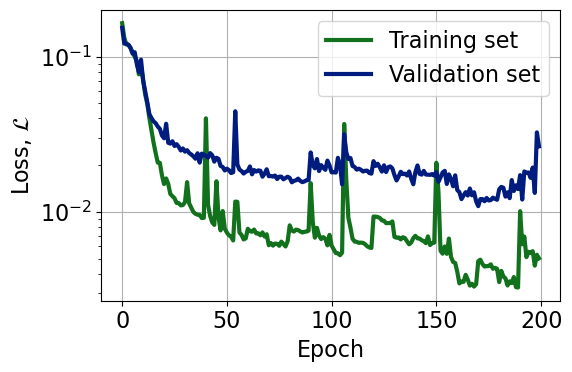

In [11]:
training_losses = np.array(history['training_losses'])
validation_losses = np.array(history['validation_losses'])

print(training_losses[-1])
print(validation_losses[-1])

fig = plt.figure(figsize=(6,4), dpi=100)
plt.plot(training_losses, linewidth=3, color=sns.palettes.SEABORN_PALETTES['dark'][2], label='Training set')
plt.plot(validation_losses, linewidth=3, color=sns.palettes.SEABORN_PALETTES['dark'][0], label='Validation set')
plt.yscale('log')

plt.grid()
plt.legend(loc='best')
plt.xlabel('Epoch')
plt.ylabel(r'Loss, $\mathcal{L}$')
plt.tight_layout()
plt.show()

### Validate on all datasets

In [12]:
results_dict = {}

for dataset_name in dataset_dict:

    sensor_voltage = dataset_dict[dataset_name]['sensor_voltage']
    tip_position = dataset_dict[dataset_name]['tip_position']

    # scale dateset
    X_series = th.Tensor(observation_scaler.transform(sensor_voltage)).unsqueeze(1)
    Y_series = th.Tensor(action_scaler.transform(tip_position)).unsqueeze(1)

    # reset network states and predict
    net.reset_states()
    Y_hats = net.predict(X_series)

    # inverse transform to original scale
    real_pos_tips = action_scaler.inverse_transform(Y_series.squeeze())
    pred_pos_tips = action_scaler.inverse_transform(Y_hats.squeeze())
    
    errors = np.linalg.norm(real_pos_tips - pred_pos_tips, axis=1)

    # save results
    results_dict[dataset_name] = dict(real_pos_tips=real_pos_tips,
                                      pred_pos_tips=pred_pos_tips,
                                      errors=errors)

0it [00:00, ?it/s]

10801it [00:17, 600.37it/s]
5401it [00:10, 494.81it/s]
16201it [00:23, 688.34it/s] 


In [55]:
errors_1 = results_dict['dataset_res_sens_pos_1.mat']['errors']
errors_2 = results_dict['dataset_res_sens_pos_2.mat']['errors']
errors_3 = results_dict['dataset_res_sens_pos_3.mat']['errors']

all_errors = [errors_1, errors_2, errors_3]

for i, errors in enumerate(all_errors):
    print(i + 1)
    L = 60 # mm

    print('mean pm std: %.1f mm pm %.1f mm ' \
          '(%.1f%%L pm %.1f%%L)' % (np.mean(errors), np.std(errors), np.mean(errors) / L * 100, np.std(errors) / L * 100))
    #print('min: %.1f mm (%.1f%%L)' % (np.min(errors), np.min(errors) / L * 100))
    print('max: %.1f mm (%.1f%%L)' % (np.max(errors), np.max(errors) / L * 100))

1
mean pm std: 4.9 mm pm 2.9 mm (8.1%L pm 4.8%L)
max: 17.5 mm (29.1%L)
2
mean pm std: 1.2 mm pm 1.1 mm (2.0%L pm 1.8%L)
max: 10.3 mm (17.2%L)
3
mean pm std: 2.3 mm pm 1.9 mm (3.8%L pm 3.2%L)
max: 10.8 mm (18.0%L)


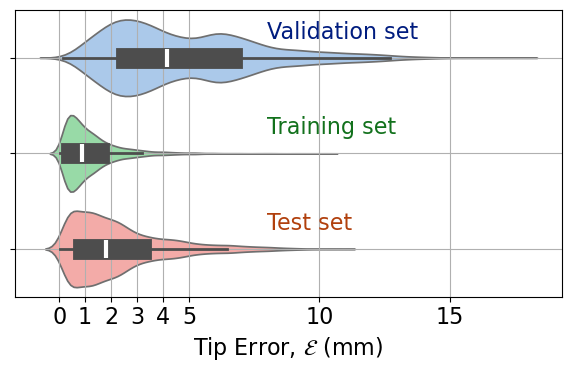

In [56]:
fig = plt.figure(figsize=(6,4), dpi=100)

#sns.stripplot(data=all_errors, size=3, jitter=True, alpha=0.2, orient='h')
ax = sns.violinplot(data=all_errors, orient='h',
                   inner='box',
                   palette=sns.palettes.SEABORN_PALETTES['pastel6'][:3], # sns.palettes.SEABORN_PALETTES.keys()
                   inner_kws=dict(box_width=15,
                                  whis_width=2, color=".3", ))

plt.annotate(text='Training set', xy=(8, 1 - 0.2), color=sns.palettes.SEABORN_PALETTES['dark'][2])
plt.annotate(text='Validation set', xy=(8, 0 - 0.2), color=sns.palettes.SEABORN_PALETTES['dark'][0])
plt.annotate(text='Test set', xy=(8, 2 - 0.2), color=sns.palettes.SEABORN_PALETTES['dark'][1])

plt.xlabel('Tip Error, $\mathcal{E}$ (mm)')
plt.yticks([0,1,2], [])
plt.xticks([0,1,2,3,4,5,10,15])
plt.grid()
plt.tight_layout()
plt.show()

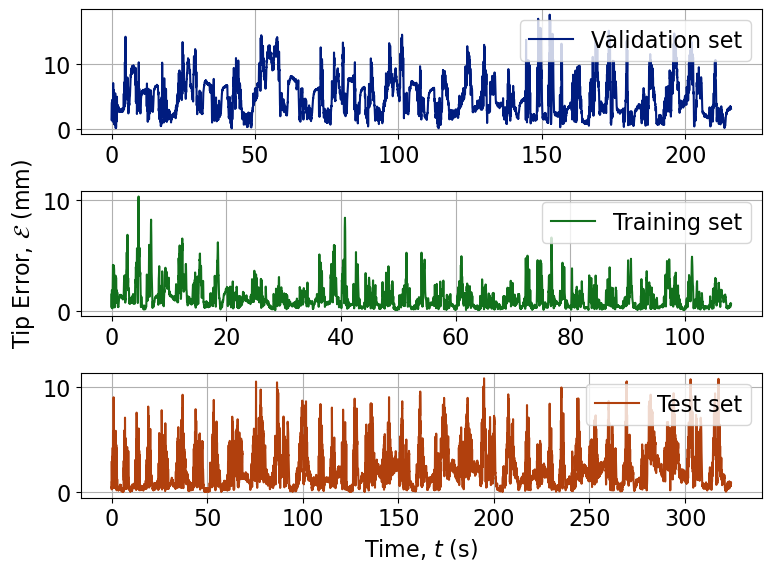

In [57]:
sampling_frequency = 50 # Hz
n_samples_1 = errors_1.shape[0]
n_samples_2 = errors_2.shape[0]
n_samples_3 = errors_3.shape[0]

total_time_1 = n_samples_1 / sampling_frequency
total_time_2 = n_samples_2 / sampling_frequency
total_time_3 = n_samples_3 / sampling_frequency

t_1 = np.linspace(0, total_time_1, num=n_samples_1)
t_2 = np.linspace(0, total_time_2, num=n_samples_2)
t_3 = np.linspace(0, total_time_3, num=n_samples_3)

fig, (ax1, ax2, ax3) =  plt.subplots(figsize=(8,6), nrows=3, ncols=1, sharex=False, dpi=100)
ax1.plot(t_1, errors_1, color=sns.palettes.SEABORN_PALETTES['dark'][0], label='Validation set')
ax2.plot(t_2, errors_2, color=sns.palettes.SEABORN_PALETTES['dark'][2], label='Training set')
ax3.plot(t_3, errors_3, color=sns.palettes.SEABORN_PALETTES['dark'][1], label='Test set')

ax1.legend(loc='upper right')
ax2.legend(loc='upper right')
ax3.legend(loc='upper right')
ax1.grid()
ax2.grid()
ax3.grid()

plt.xlabel('Time, $t$ (s)')
ax2.set_ylabel('Tip Error, $\mathcal{E}$ (mm)')
plt.tight_layout()
#plt.plot(errors_2)
#plt.plot(errors_3)

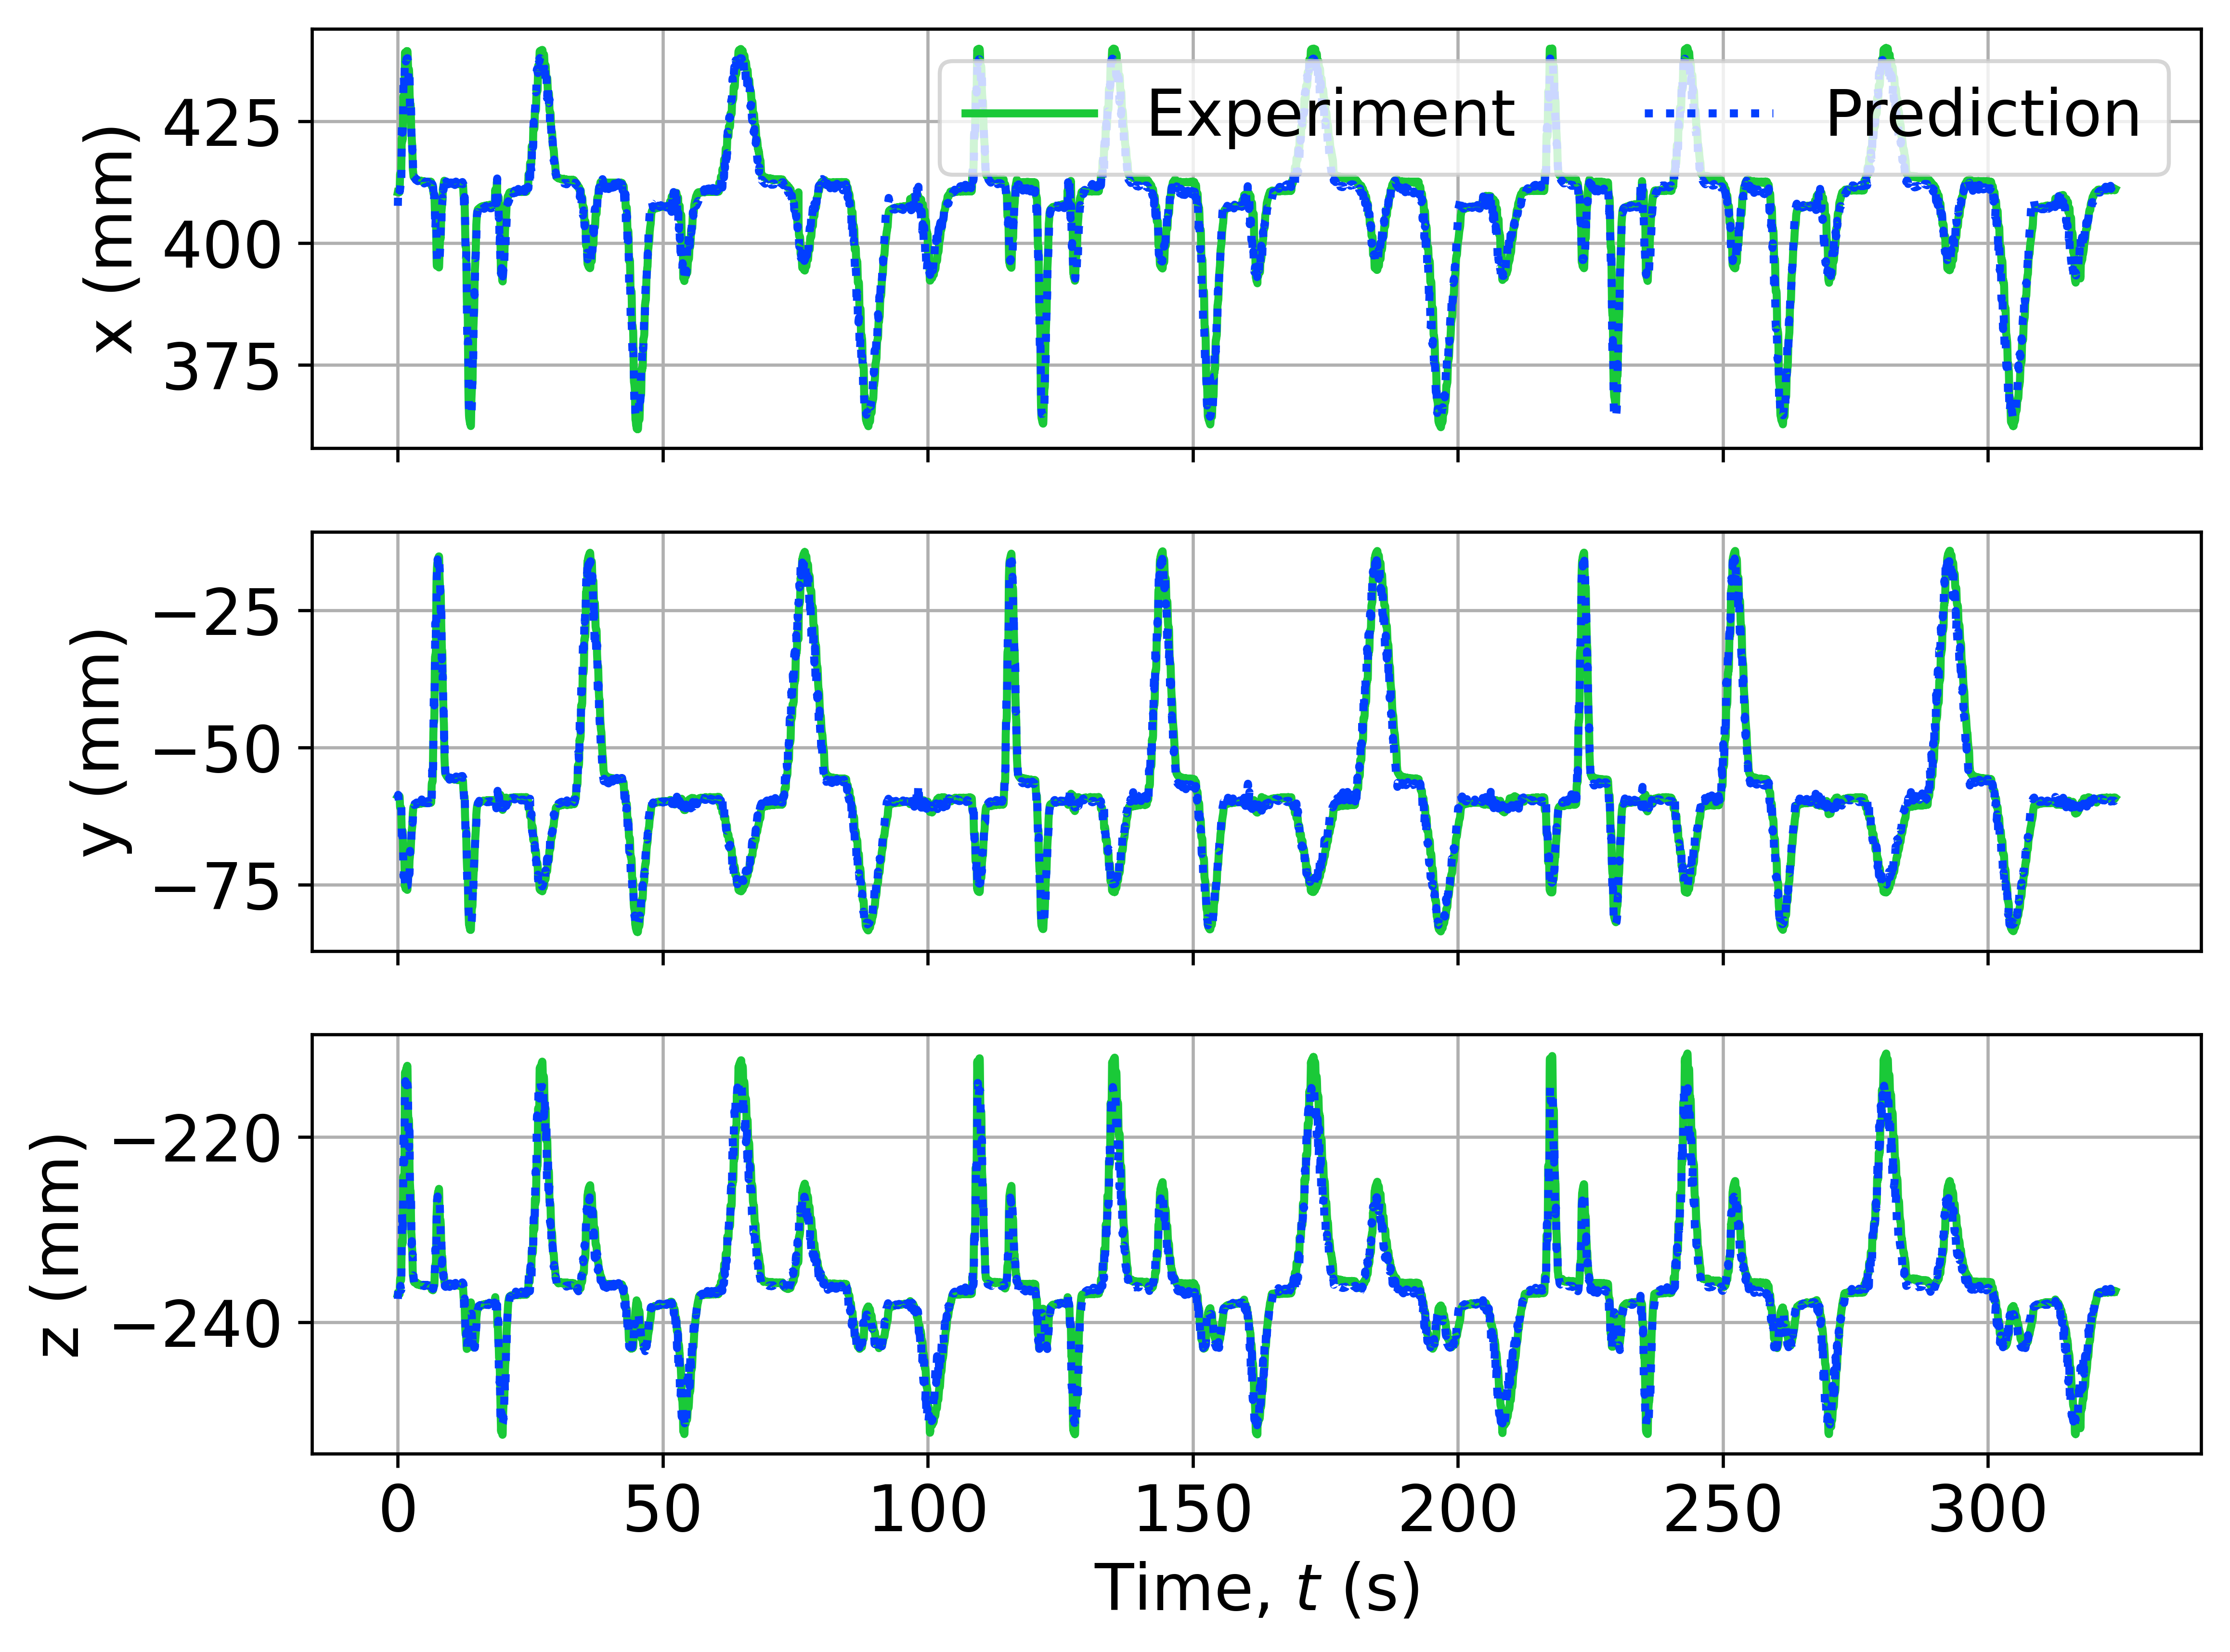

In [58]:
real_pos_tips = results_dict['dataset_res_sens_pos_3.mat']['real_pos_tips']
pred_pos_tips = results_dict['dataset_res_sens_pos_3.mat']['pred_pos_tips']

n_samples = real_pos_tips.shape[0]
total_time = n_samples / sampling_frequency
t = np.linspace(0, total_time, num=n_samples)

# positions
fig, (ax1, ax2, ax3) =  plt.subplots(figsize=(8,6), nrows=3, ncols=1, sharex=True, dpi=600)
ax1.plot(t, real_pos_tips[:, 0], linewidth=2, color=sns.palettes.SEABORN_PALETTES['bright'][2], label='Experiment')
ax1.plot(t, pred_pos_tips[:, 0], linewidth=2, linestyle=':', color=sns.palettes.SEABORN_PALETTES['bright'][0], label='Prediction')

ax2.plot(t, real_pos_tips[:, 1], linewidth=2, color=sns.palettes.SEABORN_PALETTES['bright'][2])
ax2.plot(t, pred_pos_tips[:, 1], linewidth=2, linestyle=':', color=sns.palettes.SEABORN_PALETTES['bright'][0])

ax3.plot(t, real_pos_tips[:, 2], linewidth=2, color=sns.palettes.SEABORN_PALETTES['bright'][2],)
ax3.plot(t, pred_pos_tips[:, 2], linewidth=2, linestyle=':', color=sns.palettes.SEABORN_PALETTES['bright'][0])

ax1.set_ylabel('x (mm)')
ax2.set_ylabel('y (mm)')
ax3.set_ylabel('z (mm)')
ax1.grid()
ax2.grid()
ax3.grid()
plt.xlabel('Time, $t$ (s)')
ax1.legend(loc='upper right', ncols=2)
plt.tight_layout()
plt.show()

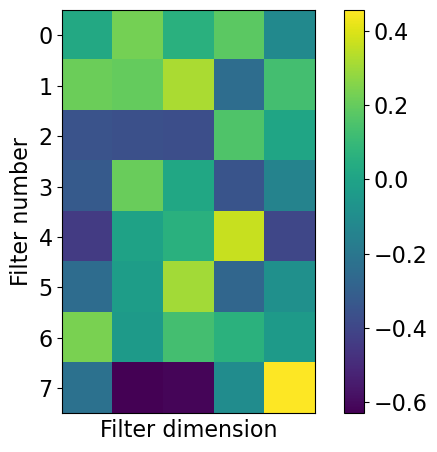

In [78]:
filters = list(net.conv.parameters())[0].detach().numpy().squeeze()
filter_bias = list(net.conv.parameters())[1].detach().numpy()#.squeeze()

plt.imshow(filters)
#plt.imshow(filter_bias.reshape(1,-1))

plt.xticks([])
plt.ylabel('Filter number')
plt.xlabel('Filter dimension')

plt.colorbar()
plt.tight_layout()
plt.show()

In [ ]:
f, (ax, ax2, ax3) = plt.subplots(1, 3, figsize=(10,6), sharey=False, facecolor='w')

# plot the same data on both axes
ax.plot(t, real_pos_tips[:,0])
ax.plot(t, pred_pos_tips[:,0])

ax2.plot(t, real_pos_tips[:,0])
ax2.plot(t, pred_pos_tips[:,0])

ax3.plot(t, real_pos_tips[:,0])
ax3.plot(t, pred_pos_tips[:,0])

ax.set_xlim(t[0]-1, 20)
ax2.set_xlim(40, 60)
ax3.set_xlim(80, t[-1]+1)

# hide the spines between ax and ax2
ax.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax3.spines['left'].set_visible(False)

ax.yaxis.tick_left()
#ax.tick_params(labelright='off')
#ax2.tick_params(labelright='off')
#ax2.tick_params(labelleft='off')

ax3.yaxis.tick_right()

ax2.set_yticklabels([])

# This looks pretty good, and was fairly painless, but you can get that
# cut-out diagonal lines look with just a bit more work. The important
# thing to know here is that in axes coordinates, which are always
# between 0-1, spine endpoints are at these locations (0, 0), (0, 1),
# (1, 0), and (1, 1).  Thus, we just need to put the diagonals in the
# appropriate corners of each of our axes, and so long as we use the
# right transform and disable clipping.

d = .015  # how big to make the diagonal lines in axes coordinates
# arguments to pass plot, just so we don't keep repeating them
kwargs = dict(transform=ax.transAxes, color='k', clip_on=False)
ax.plot((1-d, 1+d), (-d, +d), **kwargs)
ax.plot((1-d, 1+d), (1-d, 1+d), **kwargs)

kwargs.update(transform=ax2.transAxes)  # switch to the bottom axes
ax2.plot((-d, +d), (1-d, 1+d), **kwargs)
ax2.plot((-d, +d), (-d, +d), **kwargs)

kwargs.update(transform=ax3.transAxes)  # switch to the bottom axes
ax3.plot((-d, +d), (1-d, 1+d), **kwargs)
ax3.plot((-d, +d), (-d, +d), **kwargs)

ax.grid(); ax2.grid(); ax3.grid()

# What's cool about this is that now if we vary the distance between
# ax and ax2 via f.subplots_adjust(hspace=...) or plt.subplot_tool(),
# the diagonal lines will move accordingly, and stay right at the tips
# of the spines they are 'breaking'

plt.show()

In [ ]:
sns.palettes.SEABORN_PALETTES.keys()

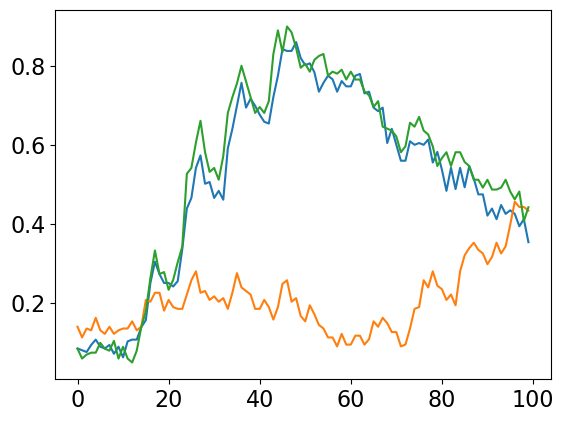

In [84]:
plt.plot(X_val_series[:100, 0].detach().numpy())

In [ ]:
#nn.Transformer()

### Predictions

In [ ]:
dataset = dataset_dict['dataset_res_sens_pos_1.mat'] # 2 train, 1 val

sensor_voltage = dataset['sensor_voltage']       # (10801, 3)
sensor_resistance = dataset['sensor_resistance'] # (10801, 3)
tip_position = dataset['tip_position'] # (10801, 3) convert mm to meters

X_val_series = th.Tensor(observation_scaler.transform(sensor_voltage)).unsqueeze(1)
Y_val_series = th.Tensor(action_scaler.transform(tip_position)).unsqueeze(1)

X_val_series.shape, Y_val_series.shape

In [ ]:
net.reset_states()
loss_value, Y_hats = net.validate(X_val_series, Y_val_series, loss_fn)

Y_hats.shape, loss_value

In [ ]:
# inverse transform to original scale
real_pos_tips = action_scaler.inverse_transform(Y_val_series.squeeze())
pred_pos_tips = action_scaler.inverse_transform(Y_hats.squeeze())

errors = np.linalg.norm(real_pos_tips - pred_pos_tips, axis=1)

mean_error = np.mean(errors)
std_error  = np.std(errors)

L = 60 # mm

print("error (mm): % .1f pm %.1f" % (mean_error, std_error))
print("error (%%): %.1f pm %.1f" % (mean_error / L * 100, std_error / L * 100))
print("min: %.1f mm (%.1f %%)" % (np.min(errors), np.min(errors) / L * 100))
print("max: %.1f mm (%.1f %%)" % (np.max(errors), np.max(errors) / L * 100))

plt.plot(errors)
plt.show()

#plt.boxplot(errors)
#plt.show()

In [ ]:
# positions
fig, (ax1, ax2, ax3) =  plt.subplots(figsize=(8,6), nrows=3, ncols=1)
ax1.plot(real_pos_tips[:, 0], color='green', label='Experiment')
ax1.plot(pred_pos_tips[:, 0], color='blue', label='Prediction')

ax2.plot(real_pos_tips[:, 1], color='green')
ax2.plot(pred_pos_tips[:, 1], color='blue')

ax3.plot(real_pos_tips[:, 2], color='green')
ax3.plot(pred_pos_tips[:, 2], color='blue')

ax1.set_ylabel('x (mm)')
ax2.set_ylabel('y (mm)')
ax3.set_ylabel('z (mm)')
plt.xlabel('Time, $t$ (s)')
ax1.legend(loc='best', ncols=2)
plt.tight_layout()
plt.show()